In [57]:
is_causal = True # Set to False for future leakage
run_training = True  # Set to True to run training (takes time)

In [58]:
import pandas as pd
import glob
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import clip_grad_norm_, spectral_norm
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
import random
import numpy as np
import matplotlib.pyplot as plt

In [59]:
import sys
sys.path.append("../EDAF-Group_6-PV_Forecasting")

In [60]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [61]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [62]:
pv_data = pd.read_csv("../data/PV_2022_hourly.csv")
weather_data = pd.read_csv("../data/Weather_clean_NEMS.csv")

In [63]:
df_pv = pd.DataFrame(pv_data)
df_weather = pd.DataFrame(weather_data)

In [64]:
df_pv.info()

<class 'pandas.DataFrame'>
RangeIndex: 8758 entries, 0 to 8757
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   TimestampInUtc  8758 non-null   str    
 1   pv              8758 non-null   float64
dtypes: float64(1), str(1)
memory usage: 137.0 KB


In [65]:
weather_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   timestamp                    8760 non-null   str    
 1   Temperature                  8760 non-null   float64
 2   Sunshine Duration            8760 non-null   float64
 3   Shortwave Radiation          8760 non-null   float64
 4   Direct Shortwave Radiation   8760 non-null   float64
 5   Diffuse Shortwave Radiation  8760 non-null   float64
 6   Snowfall Amount              8760 non-null   float64
 7   Relative Humidity            8760 non-null   float64
 8   Cloud Cover Total            8760 non-null   float64
dtypes: float64(8), str(1)
memory usage: 616.1 KB


In [66]:
df_pv.head()

,TimestampInUtc,pv
0,2022-01-01 00:00:00,0.0
1,2022-01-01 01:00:00,0.0
2,2022-01-01 02:00:00,0.0
3,2022-01-01 03:00:00,0.0
4,2022-01-01 04:00:00,0.0


In [67]:
df_weather.head()

,timestamp,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total
0,2022-01-01 00:00:00,9.657269,0.0,0.0,0.0,0.0,0.0,29.0,0.0
1,2022-01-01 01:00:00,9.457270,0.0,0.0,0.0,0.0,0.0,29.0,0.0
2,2022-01-01 02:00:00,9.787270,0.0,0.0,0.0,0.0,0.0,28.0,0.0
3,2022-01-01 03:00:00,9.467270,0.0,0.0,0.0,0.0,0.0,28.0,0.0
4,2022-01-01 04:00:00,8.797270,0.0,0.0,0.0,0.0,0.0,30.0,0.0


In [68]:
df_pv.shape

(8758, 2)

In [69]:
df_weather.shape

(8760, 9)

In [70]:
df_pv[-10:]

,TimestampInUtc,pv
8748,2022-12-31 12:00:00,50.272210
8749,2022-12-31 13:00:00,31.335803
8750,2022-12-31 14:00:00,6.479349
8751,2022-12-31 15:00:00,0.000000
8752,2022-12-31 16:00:00,0.000000
8753,2022-12-31 17:00:00,0.000000
8754,2022-12-31 18:00:00,0.000000
8755,2022-12-31 19:00:00,0.000000
8756,2022-12-31 20:00:00,0.000000
8757,2022-12-31 21:00:00,0.000000


In [71]:
df_pv["TimestampInUtc"] = pd.to_datetime(df_pv["TimestampInUtc"])

last_time = df_pv["TimestampInUtc"].iloc[-1]

new_rows = pd.DataFrame({
    "TimestampInUtc": [
        last_time + pd.Timedelta(hours=1),
        last_time + pd.Timedelta(hours=2)
    ],
    "pv": [0, 0]
})

df_pv = pd.concat([df_pv, new_rows], ignore_index=True)

In [72]:
df_pv[-10:]

,TimestampInUtc,pv
8750,2022-12-31 14:00:00,6.479349
8751,2022-12-31 15:00:00,0.000000
8752,2022-12-31 16:00:00,0.000000
8753,2022-12-31 17:00:00,0.000000
8754,2022-12-31 18:00:00,0.000000
8755,2022-12-31 19:00:00,0.000000
8756,2022-12-31 20:00:00,0.000000
8757,2022-12-31 21:00:00,0.000000
8758,2022-12-31 22:00:00,0.000000
8759,2022-12-31 23:00:00,0.000000


In [73]:
df_pv.shape

(8760, 2)

In [74]:
df_weather.shape

(8760, 9)

In [75]:
df_merged = pd.concat([df_pv, df_weather], axis=1)

In [76]:
df_merged.head()

,TimestampInUtc,pv,timestamp,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total
0,2022-01-01 00:00:00,0.0,2022-01-01 00:00:00,9.657269,0.0,0.0,0.0,0.0,0.0,29.0,0.0
1,2022-01-01 01:00:00,0.0,2022-01-01 01:00:00,9.457270,0.0,0.0,0.0,0.0,0.0,29.0,0.0
2,2022-01-01 02:00:00,0.0,2022-01-01 02:00:00,9.787270,0.0,0.0,0.0,0.0,0.0,28.0,0.0
3,2022-01-01 03:00:00,0.0,2022-01-01 03:00:00,9.467270,0.0,0.0,0.0,0.0,0.0,28.0,0.0
4,2022-01-01 04:00:00,0.0,2022-01-01 04:00:00,8.797270,0.0,0.0,0.0,0.0,0.0,30.0,0.0


In [77]:
df_merged.iloc[-10:]

,TimestampInUtc,pv,timestamp,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total
8750,2022-12-31 14:00:00,6.479349,2022-12-31 14:00:00,15.597270,40.851063,307.05000,175.559000,131.490980,0.0,64.0,30.000002
8751,2022-12-31 15:00:00,0.000000,2022-12-31 15:00:00,14.687269,40.851063,246.53000,138.154100,108.375900,0.0,64.0,30.000002
8752,2022-12-31 16:00:00,0.000000,2022-12-31 16:00:00,13.027269,47.744680,147.73999,80.121185,67.618805,0.0,68.0,19.200000
8753,2022-12-31 17:00:00,0.000000,2022-12-31 17:00:00,11.937269,33.407090,32.04000,16.751293,15.288709,0.0,68.0,30.000002
8754,2022-12-31 18:00:00,0.000000,2022-12-31 18:00:00,12.117270,0.000000,0.00000,0.000000,0.000000,0.0,61.0,18.600000
8755,2022-12-31 19:00:00,0.000000,2022-12-31 19:00:00,11.847270,0.000000,0.00000,0.000000,0.000000,0.0,59.0,100.000000
8756,2022-12-31 20:00:00,0.000000,2022-12-31 20:00:00,11.437269,0.000000,0.00000,0.000000,0.000000,0.0,58.0,95.000000
8757,2022-12-31 21:00:00,0.000000,2022-12-31 21:00:00,10.897269,0.000000,0.00000,0.000000,0.000000,0.0,58.0,20.000000
8758,2022-12-31 22:00:00,0.000000,2022-12-31 22:00:00,10.407269,0.000000,0.00000,0.000000,0.000000,0.0,59.0,10.000000
8759,2022-12-31 23:00:00,0.000000,2022-12-31 23:00:00,10.557270,0.000000,0.00000,0.000000,0.000000,0.0,58.0,26.000000


In [78]:
df_merged.shape

(8760, 11)

In [79]:
df_merged['timestamp'] = pd.to_datetime(df_merged['timestamp'])
df_merged["hour"] = df_merged["timestamp"].dt.hour
df_merged["day_of_year"] = df_merged["timestamp"].dt.dayofyear
df_merged["month"] = df_merged["timestamp"].dt.month

In [80]:
df_merged.columns

Index(['TimestampInUtc', 'pv', 'timestamp', 'Temperature', 'Sunshine Duration',
       'Shortwave Radiation', 'Direct Shortwave Radiation',
       'Diffuse Shortwave Radiation', 'Snowfall Amount', 'Relative Humidity',
       'Cloud Cover Total', 'hour', 'day_of_year', 'month'],
      dtype='str')

In [81]:
df_merged["hour_sin"]  = np.sin(2 * np.pi * df_merged["hour"] / 24)
df_merged["hour_cos"]  = np.cos(2 * np.pi * df_merged["hour"] / 24)

df_merged["month_sin"] = np.sin(2 * np.pi * df_merged["month"] / 12)
df_merged["month_cos"] = np.cos(2 * np.pi * df_merged["month"] / 12)

df_merged["doy_sin"] = np.sin(2 * np.pi * df_merged["day_of_year"] / 365)
df_merged["doy_cos"] = np.cos(2 * np.pi * df_merged["day_of_year"] / 365)

In [82]:
df_merged.iloc[-744:]

,TimestampInUtc,pv,timestamp,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total,hour,day_of_year,month,hour_sin,hour_cos,month_sin,month_cos,doy_sin,doy_cos
8016,2022-12-01 00:00:00,0.0,2022-12-01 00:00:00,2.387269,0.0,0.0,0.0,0.0,0.0,90.0,100.0,0,335,12,0.000000,1.000000,-2.449294e-16,1.0,-4.937756e-01,0.869589
8017,2022-12-01 01:00:00,0.0,2022-12-01 01:00:00,2.257269,0.0,0.0,0.0,0.0,0.0,90.0,100.0,1,335,12,0.258819,0.965926,-2.449294e-16,1.0,-4.937756e-01,0.869589
8018,2022-12-01 02:00:00,0.0,2022-12-01 02:00:00,2.057269,0.0,0.0,0.0,0.0,0.0,91.0,100.0,2,335,12,0.500000,0.866025,-2.449294e-16,1.0,-4.937756e-01,0.869589
8019,2022-12-01 03:00:00,0.0,2022-12-01 03:00:00,1.737269,0.0,0.0,0.0,0.0,0.0,93.0,100.0,3,335,12,0.707107,0.707107,-2.449294e-16,1.0,-4.937756e-01,0.869589
8020,2022-12-01 04:00:00,0.0,2022-12-01 04:00:00,1.277269,0.0,0.0,0.0,0.0,0.0,94.0,100.0,4,335,12,0.866025,0.500000,-2.449294e-16,1.0,-4.937756e-01,0.869589
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2022-12-31 19:00:00,0.0,2022-12-31 19:00:00,11.847270,0.0,0.0,0.0,0.0,0.0,59.0,100.0,19,365,12,-0.965926,0.258819,-2.449294e-16,1.0,6.432491e-16,1.000000
8756,2022-12-31 20:00:00,0.0,2022-12-31 20:00:00,11.437269,0.0,0.0,0.0,0.0,0.0,58.0,95.0,20,365,12,-0.866025,0.500000,-2.449294e-16,1.0,6.432491e-16,1.000000
8757,2022-12-31 21:00:00,0.0,2022-12-31 21:00:00,10.897269,0.0,0.0,0.0,0.0,0.0,58.0,20.0,21,365,12,-0.707107,0.707107,-2.449294e-16,1.0,6.432491e-16,1.000000
8758,2022-12-31 22:00:00,0.0,2022-12-31 22:00:00,10.407269,0.0,0.0,0.0,0.0,0.0,59.0,10.0,22,365,12,-0.500000,0.866025,-2.449294e-16,1.0,6.432491e-16,1.000000


In [83]:
df_merged.drop(columns=['TimestampInUtc', 'timestamp', 'hour', 'day_of_year', 'month'], inplace=True)

In [84]:
df_test = df_merged.iloc[-744:].copy()
df_train = df_merged.iloc[:-744].copy()

In [85]:
df_train.columns

Index(['pv', 'Temperature', 'Sunshine Duration', 'Shortwave Radiation',
       'Direct Shortwave Radiation', 'Diffuse Shortwave Radiation',
       'Snowfall Amount', 'Relative Humidity', 'Cloud Cover Total', 'hour_sin',
       'hour_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos'],
      dtype='str')

In [86]:
TARGET_COL = "pv"

CONTINUOUS_FEATURES = [
    "Temperature", "Sunshine Duration", "Shortwave Radiation",
    "Direct Shortwave Radiation", "Diffuse Shortwave Radiation",
    "Snowfall Amount", "Relative Humidity", "Cloud Cover Total"
]

CYCLIC_FEATURES = [
    "hour_sin", "hour_cos",
    "month_sin", "month_cos",
    "doy_sin", "doy_cos"
]

CATEGORICAL_FEATURES = []

In [87]:
from sklearn.preprocessing import StandardScaler
import numpy as np

def prepare_data(df_train, df_test):

    # ---------- continuous ----------
    Xc_train = df_train[CONTINUOUS_FEATURES].values
    Xc_test  = df_test[CONTINUOUS_FEATURES].values

    # ---------- cyclic ----------
    Xcy_train = df_train[CYCLIC_FEATURES].values
    Xcy_test  = df_test[CYCLIC_FEATURES].values

    # ---------- target (UNSCALED) ----------
    y_train = df_train[[TARGET_COL]].values.astype(np.float32)
    y_test  = df_test[[TARGET_COL]].values.astype(np.float32)

    y_train_unscaled = y_train.copy()

    # ---------- scalers ----------
    scaler_X = StandardScaler()
    scaler_y = None  # <-- no y scaling in Option A

    # fit on train
    Xc_train_scaled = scaler_X.fit_transform(Xc_train)
    Xc_test_scaled  = scaler_X.transform(Xc_test)

    # ---------- combine ----------
    X_train = np.concatenate([Xc_train_scaled, Xcy_train], axis=1).astype(np.float32)
    X_test  = np.concatenate([Xc_test_scaled,  Xcy_test],  axis=1).astype(np.float32)

    # y stays in original units (>= 0)
    return {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "scaler_X": scaler_X,
        "scaler_y": scaler_y,  # None
        "y_train_unscaled": y_train_unscaled
    }

In [88]:
data = prepare_data(df_train, df_test)

X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]

In [89]:
LOOKBACK = 168   # 7 days (tune: 24, 48, 72, 168)
HORIZON  = 24

In [90]:
def create_sequences_multistep(X, y, lookback, horizon=24):
    Xs, ys = [], []
    last_i = len(X) - lookback - horizon + 1
    for i in range(last_i):
        Xs.append(X[i:i+lookback])                     # (lookback, n_features)
        y_window = y[i+lookback:i+lookback+horizon] 
        y_window = y_window[:, 0]# (horizon,)
        ys.append(y_window
                  )
    return np.array(Xs), np.array(ys)

In [91]:
X_train_seq, y_train_seq = create_sequences_multistep(X_train, y_train, LOOKBACK, HORIZON)
X_test_seq, y_test_seq = create_sequences_multistep(X_test, y_test, LOOKBACK, HORIZON)

In [92]:
print("Train seq:", X_train_seq.shape, y_train_seq.shape)
print("Test  seq:", X_test_seq.shape,  y_test_seq.shape)

Train seq: (7825, 168, 14) (7825, 24)
Test  seq: (553, 168, 14) (553, 24)


In [93]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [94]:
class Chomp1d(nn.Module):
    """Remove extra padding from causal conv to keep output length same as input"""
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

In [95]:
class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, dilation, padding, dropout, causal):
        super().__init__()
        # Replace weight_norm with spectral_norm
        self.conv1 = spectral_norm(nn.Conv1d(in_channels, out_channels, kernel_size,
                                              stride=stride, padding=padding, dilation=dilation))
        if causal:
            self.chomp1 = Chomp1d(padding)
        else:
            self.chomp1 = nn.Identity()
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = spectral_norm(nn.Conv1d(out_channels, out_channels, kernel_size,
                                              stride=stride, padding=padding, dilation=dilation))
        if causal:
            self.chomp2 = Chomp1d(padding)
        else:
            self.chomp2 = nn.Identity()
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1,
                                 self.conv2, self.chomp2, self.relu2, self.dropout2)
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

In [96]:
class TCN(nn.Module):
    def __init__(self, input_size, output_size, num_channels, kernel_size=2, dropout=0.2, is_causal=True):
        super().__init__()
        layers = []
        for i, out_ch in enumerate(num_channels):
            in_ch = input_size if i == 0 else num_channels[i-1]
            dilation = 2**i

            if is_causal:
                padding_value = (kernel_size - 1) * dilation
            else:
                padding_value = ((kernel_size - 1) * dilation) // 2

            layers.append(
                TemporalBlock(
                    in_ch, out_ch, kernel_size,
                    stride=1, dilation=dilation,
                    padding=padding_value,
                    dropout=dropout,
                    causal=is_causal
                )
            )

        self.network = nn.Sequential(*layers)
        self.fc = nn.Linear(num_channels[-1], output_size)

    def forward(self, x):
        # if x is (B, T, F), uncomment next line:
        x = x.transpose(1, 2)  # -> (B, F, T)

        out = self.network(x)
        out = out[:, :, -1]
        out = self.fc(out)

        # Option 2A (unscaled y): prefer softplus over relu
        out = F.relu(out)

        return out

In [97]:
def get_lr_with_warmup(epoch, base_lr, warmup_epochs):
    if warmup_epochs == 0 or epoch >= warmup_epochs:
        return base_lr
    else:
        return base_lr * (epoch + 1) / warmup_epochs

In [98]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total, n = 0.0, 0
    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device)

        # Force yb to be (B, 24)
        if yb.ndim == 3 and yb.shape[-1] == 1:
            yb = yb.squeeze(-1)   # (B, 24, 1) -> (B, 24)

        optimizer.zero_grad()
        pred = model(Xb)

        # Hard check (this will tell you immediately what's wrong)
        assert pred.shape == yb.shape, f"pred {pred.shape} vs y {yb.shape}"

        loss = criterion(pred, yb)
        loss.backward()
        clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item() * Xb.size(0)
        n += Xb.size(0)
    return total / n


@torch.no_grad()
def eval_one_epoch(model, loader, criterion):
    model.eval()
    total, n = 0.0, 0
    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device)

        if yb.ndim == 3 and yb.shape[-1] == 1:
            yb = yb.squeeze(-1)

        pred = model(Xb)

        assert pred.shape == yb.shape, f"pred {pred.shape} vs y {yb.shape}"

        loss = criterion(pred, yb)
        total += loss.item() * Xb.size(0)
        n += Xb.size(0)
    return total / n


In [ ]:
# Hyperparams
BATCH_SIZE = 32
EPOCHS = 20          # <--- more epochs
LR = 1e-3

NUM_CHANNELS = [32, 32, 32, 32]
KERNEL_SIZE = 3
DROPOUT = 0.2

criterion = torch.nn.HuberLoss(delta=1.0)#nn.MSELoss()

SAVE_DIR = "./checkpoints/huber" #Softplus+ nn.smooth1loss(beta=50)
os.makedirs(SAVE_DIR, exist_ok=True)


@torch.no_grad()
def eval_metrics(model, loader):
    """Return MSE, RMSE, MAE over the whole loader (scaled space)."""
    model.eval()
    preds_all, y_all = [], []
    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device)
        if yb.ndim == 3 and yb.shape[-1] == 1:
            yb = yb.squeeze(-1)

        pred = model(Xb)
        preds_all.append(pred.cpu().numpy())
        y_all.append(yb.cpu().numpy())

    P = np.concatenate(preds_all, axis=0)
    Y = np.concatenate(y_all, axis=0)

    mse = np.mean((P - Y) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(P - Y))
    return mse, rmse, mae


def run_timeseries_kfold(X_seq, y_seq, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)

    fold_summaries = []

    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_seq), start=1):
        train_ds = SeqDataset(X_seq[tr_idx], y_seq[tr_idx])
        val_ds   = SeqDataset(X_seq[va_idx], y_seq[va_idx])

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
        val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

        model = TCN(
            input_size=X_seq.shape[-1],
            output_size=HORIZON,
            num_channels=NUM_CHANNELS,
            kernel_size=KERNEL_SIZE,
            dropout=DROPOUT
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=LR)

        history = {
            "train_loss": [],
            "val_loss": [],
            "val_rmse": [],
            "val_mae": []
        }

        best_val = float("inf")
        best_path = os.path.join(SAVE_DIR, f"fold{fold}_best.pt")

        for epoch in range(1, EPOCHS + 1):
            tr_loss = train_one_epoch(model, train_loader, optimizer, criterion)
            va_loss = eval_one_epoch(model, val_loader, criterion)
            va_mse, va_rmse, va_mae = eval_metrics(model, val_loader)

            history["train_loss"].append(tr_loss)
            history["val_loss"].append(va_loss)
            history["val_rmse"].append(va_rmse)
            history["val_mae"].append(va_mae)

            # Save best
            if va_loss < best_val:
                best_val = va_loss
                torch.save(model.state_dict(), best_path)

            if epoch % 10 == 0 or epoch == 1 or epoch == EPOCHS:
                print(f"Fold {fold}/{n_splits} | Epoch {epoch:03d} | "
                      f"train MSE {tr_loss:.5f} | val MSE {va_loss:.5f} | "
                      f"val RMSE {va_rmse:.5f} | val MAE {va_mae:.5f}")

        fold_summaries.append({
            "fold": fold,
            "best_val_mse": best_val,
            "best_path": best_path,
            "history": history
        })

        # ---- Plot curves for this fold ----
        epochs = np.arange(1, EPOCHS + 1)

        plt.figure()
        plt.plot(epochs, history["train_loss"], label="train MSE")
        plt.plot(epochs, history["val_loss"], label="val MSE")
        plt.xlabel("Epoch")
        plt.ylabel("Loss (MSE)")
        plt.title(f"Fold {fold} - Loss curves")
        plt.legend()
        plt.show()

        plt.figure()
        plt.plot(epochs, history["val_rmse"], label="val RMSE")
        plt.plot(epochs, history["val_mae"], label="val MAE")
        plt.xlabel("Epoch")
        plt.ylabel("Metric")
        plt.title(f"Fold {fold} - Metric curves (scaled space)")
        plt.legend()
        plt.show()

        print(f"Fold {fold}/{n_splits} done. Best val MSE: {best_val:.5f}")
        print(f"Saved best model to: {best_path}")

    return fold_summaries

Fold 1/5 | Epoch 001 | train MSE 25.41463 | val MSE 61.02621 | val RMSE 108.53987 | val MAE 61.37555
Fold 1/5 | Epoch 010 | train MSE 16.93786 | val MSE 36.38143 | val RMSE 68.64012 | val MAE 36.64961
Fold 1/5 | Epoch 020 | train MSE 13.50264 | val MSE 31.55317 | val RMSE 58.79907 | val MAE 31.82111


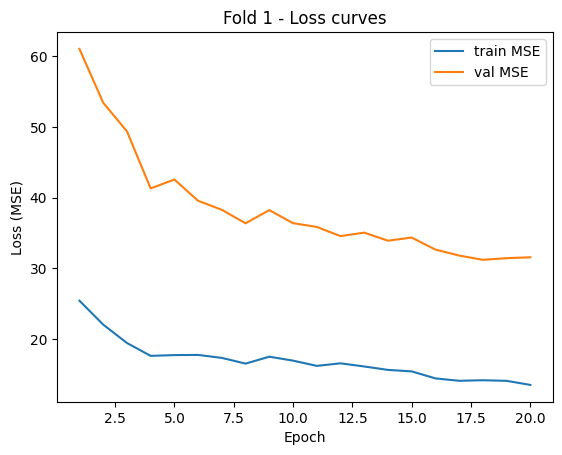

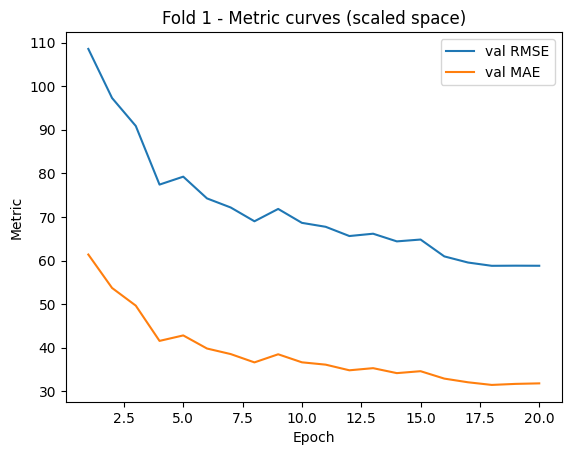

Fold 1/5 done. Best val MSE: 31.19663
Saved best model to: ./checkpoints/huber\fold1_best.pt
Fold 2/5 | Epoch 001 | train MSE 39.04124 | val MSE 68.33226 | val RMSE 113.33068 | val MAE 68.69731
Fold 2/5 | Epoch 010 | train MSE 22.30580 | val MSE 48.78818 | val RMSE 80.37711 | val MAE 49.10894
Fold 2/5 | Epoch 020 | train MSE 21.17330 | val MSE 51.11420 | val RMSE 82.96049 | val MAE 51.43485


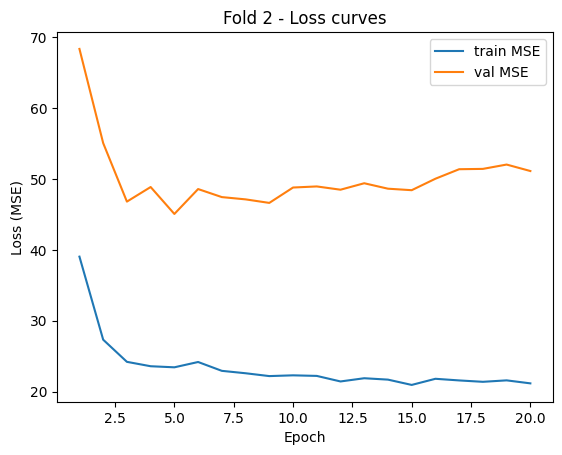

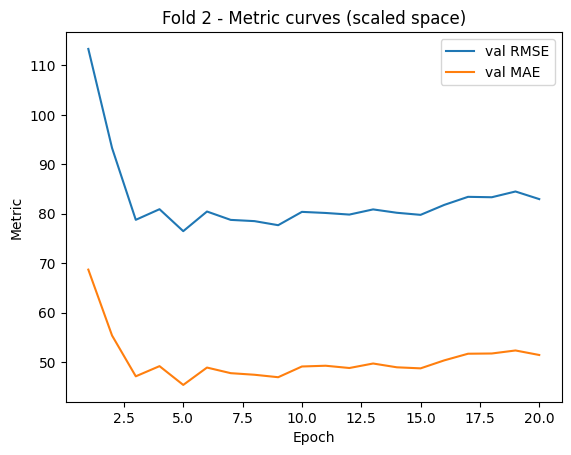

Fold 2/5 done. Best val MSE: 45.06099
Saved best model to: ./checkpoints/huber\fold2_best.pt
Fold 3/5 | Epoch 001 | train MSE 49.49410 | val MSE 64.60207 | val RMSE 103.39217 | val MAE 64.96907
Fold 3/5 | Epoch 010 | train MSE 27.70066 | val MSE 40.27816 | val RMSE 68.11765 | val MAE 40.59839
Fold 3/5 | Epoch 020 | train MSE 27.40680 | val MSE 40.28306 | val RMSE 67.85005 | val MAE 40.60331


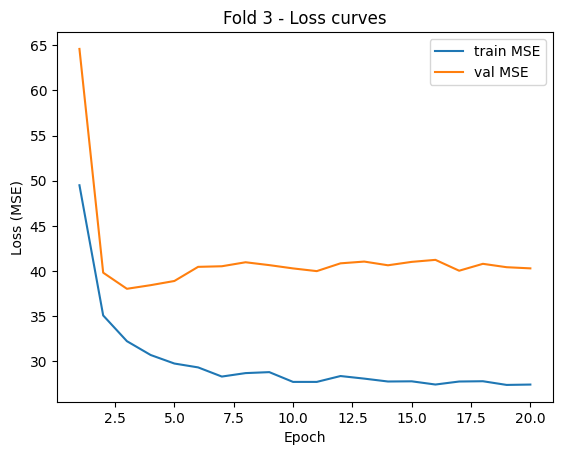

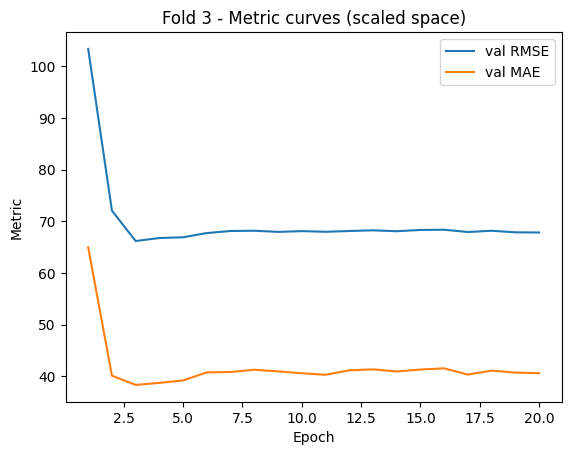

Fold 3/5 done. Best val MSE: 38.01948
Saved best model to: ./checkpoints/huber\fold3_best.pt
Fold 4/5 | Epoch 001 | train MSE 54.00389 | val MSE 36.67212 | val RMSE 64.75179 | val MAE 36.99200
Fold 4/5 | Epoch 010 | train MSE 30.83469 | val MSE 24.16687 | val RMSE 45.19270 | val MAE 24.44250
Fold 4/5 | Epoch 020 | train MSE 29.69407 | val MSE 23.73097 | val RMSE 44.66587 | val MAE 24.00510


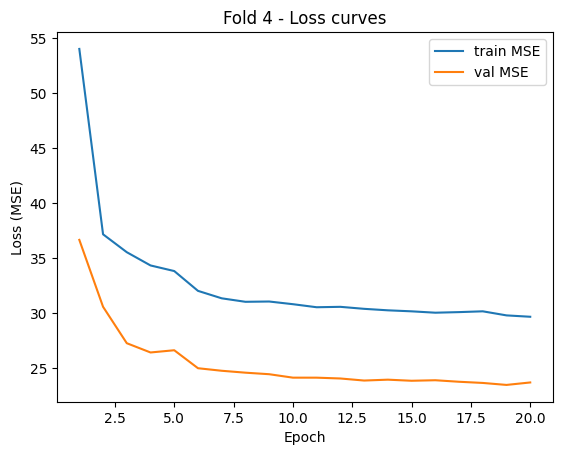

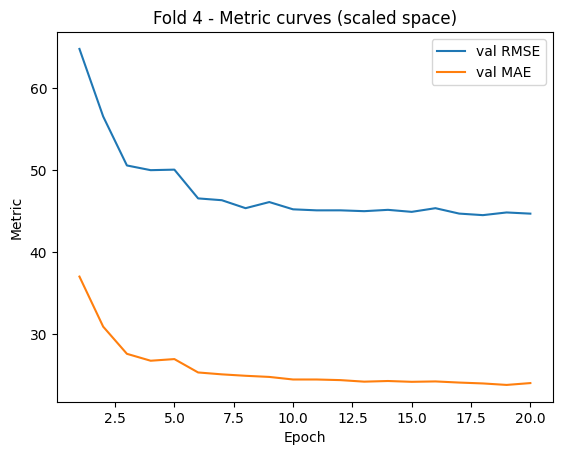

Fold 4/5 done. Best val MSE: 23.50741
Saved best model to: ./checkpoints/huber\fold4_best.pt
Fold 5/5 | Epoch 001 | train MSE 48.48459 | val MSE 15.77478 | val RMSE 30.18353 | val MAE 16.03999
Fold 5/5 | Epoch 010 | train MSE 31.33148 | val MSE 14.29530 | val RMSE 27.93288 | val MAE 14.54065
Fold 5/5 | Epoch 020 | train MSE 29.75413 | val MSE 14.07779 | val RMSE 29.29660 | val MAE 14.32090


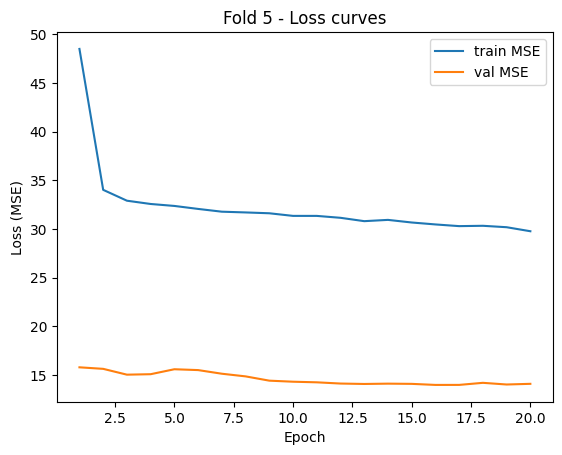

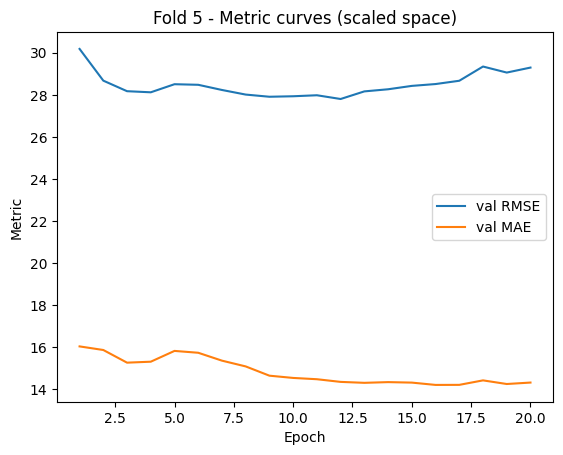

Fold 5/5 done. Best val MSE: 13.96557
Saved best model to: ./checkpoints/huber\fold5_best.pt
Best val MSE per fold: [31.19663320436068, 45.06098551837945, 38.01947988030369, 23.507411558935246, 13.965571020278462]
Mean ± std: 30.350016236451506 ± 10.874017968562427


In [100]:
if run_training:
    summaries = run_timeseries_kfold(X_train_seq, y_train_seq, n_splits=5)

    best_vals = [s["best_val_mse"] for s in summaries]
    print("Best val MSE per fold:", best_vals)
    print("Mean ± std:", np.mean(best_vals), "±", np.std(best_vals))

# Evaluation

In [112]:
# ---- Paths ----
CKPT_DIR = "../notebooks/checkpoints/huber"   # change to your folder
CKPT_PATTERN = "fold5_best.pt"  # change if your filenames differ

# ---- Forecast setup ----
LOOKBACK = 168
HORIZON = 24
TEST_SIZE = 744  # last 744 rows test

In [113]:
TARGET_COL = "pv"

CONTINUOUS_FEATURES = [
    "Temperature","Sunshine Duration","Shortwave Radiation",
    "Direct Shortwave Radiation","Diffuse Shortwave Radiation",
    "Snowfall Amount","Relative Humidity","Cloud Cover Total"
]

CYCLIC_FEATURES = [
    "hour_sin","hour_cos",
    "month_sin","month_cos",
    "doy_sin","doy_cos"
]

FEATURE_COLS = CONTINUOUS_FEATURES + CYCLIC_FEATURES


In [114]:
def load_checkpoints(ckpt_dir, pattern):
    paths = sorted(glob.glob(os.path.join(ckpt_dir, pattern)))
    if not paths:
        raise FileNotFoundError(f"No checkpoints found in {ckpt_dir} with pattern {pattern}")
    return paths

ckpt_paths = load_checkpoints(CKPT_DIR, CKPT_PATTERN)
ckpt_paths

['../notebooks/checkpoints/huber\\fold5_best.pt']

In [115]:
def predict_with_checkpoint(ckpt_path, X_seq, batch_size=256):
    # Build model with same architecture as training
    model = TCN(
        input_size=X_seq.shape[-1],
        output_size=HORIZON,
        num_channels=[32, 32, 32, 32],  # must match training
        kernel_size=3,
        dropout=0.2
    ).to(device)

    state = torch.load(ckpt_path, map_location=device)
    # if you saved {"state_dict": ...} adjust:
    if isinstance(state, dict) and "state_dict" in state:
        state = state["state_dict"]
    model.load_state_dict(state)
    model.eval()

    loader = DataLoader(SeqDataset(X_seq, np.zeros((len(X_seq), HORIZON), dtype=np.float32)),
                        batch_size=batch_size, shuffle=False)

    preds = []
    with torch.no_grad():
        for Xb, _ in loader:
            Xb = Xb.to(device)
            pb = model(Xb).cpu().numpy()
            preds.append(pb)

    return np.concatenate(preds, axis=0)  # (N, 24)


In [116]:
# Predict each fold
fold_preds = []
for p in ckpt_paths:
    pred = predict_with_checkpoint(p, X_test_seq)
    fold_preds.append(pred)
    print(os.path.basename(p), pred.shape)

fold_preds = np.stack(fold_preds, axis=0)  # (K, N, 24)
print("fold_preds:", fold_preds.shape)

fold5_best.pt (553, 24)
fold_preds: (1, 553, 24)


In [117]:
def metrics_overall(y_true, y_pred):
    mse = mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1))
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1))
    return mse, rmse, mae

def metrics_per_horizon(y_true, y_pred):
    mses, rmses, maes = [], [], []
    for h in range(y_true.shape[1]):
        mse = mean_squared_error(y_true[:, h], y_pred[:, h])
        mses.append(mse)
        rmses.append(np.sqrt(mse))
        maes.append(mean_absolute_error(y_true[:, h], y_pred[:, h]))
    return np.array(mses), np.array(rmses), np.array(maes)


In [118]:
# Evaluate each fold
for k in range(fold_preds.shape[0]):
    mse, rmse, mae = metrics_overall(y_test_seq, fold_preds[k])
    print(f"Fold {k+1}: MSE={mse:.5f} RMSE={rmse:.5f} MAE={mae:.5f}")

Fold 1: MSE=355.28955 RMSE=18.84913 MAE=10.84014


In [119]:
# Ensemble (mean across folds)
ens_pred = fold_preds.mean(axis=0)
mse, rmse, mae = metrics_overall(y_test_seq, ens_pred)
print(f"Ensemble: MSE={mse:.5f} RMSE={rmse:.5f} MAE={mae:.5f}")

Ensemble: MSE=355.28955 RMSE=18.84913 MAE=10.84014


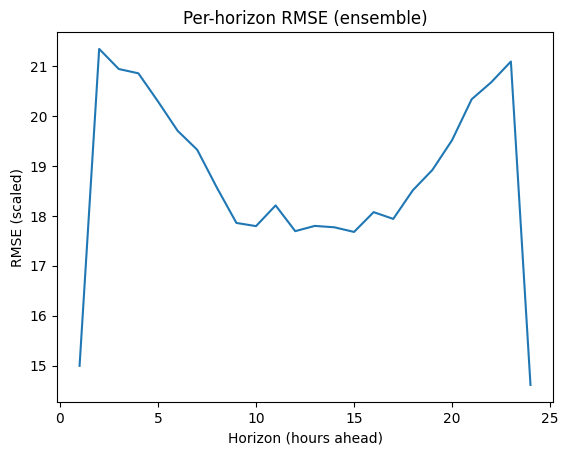

In [120]:
# Per-horizon metrics (ensemble)
mses, rmses, maes = metrics_per_horizon(y_test_seq, ens_pred)

plt.figure()
plt.plot(np.arange(1, HORIZON+1), rmses)
plt.xlabel("Horizon (hours ahead)")
plt.ylabel("RMSE (scaled)")
plt.title("Per-horizon RMSE (ensemble)")
plt.show()

In [121]:
y_test_real = y_test_seq.copy()      # already real units
ens_pred_real = ens_pred.copy()      # already real units

mse, rmse, mae = metrics_overall(y_test_real, ens_pred_real)
print(f"Ensemble (REAL units): MSE={mse:.5f} RMSE={rmse:.5f} MAE={mae:.5f}")

Ensemble (REAL units): MSE=355.28955 RMSE=18.84913 MAE=10.84014


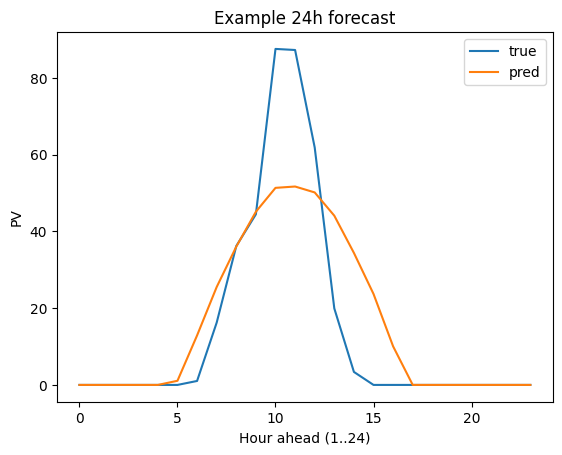

In [122]:
idx = 0  # choose which sequence in test
plt.figure()
plt.plot(y_test_real[idx], label="true")
plt.plot(ens_pred_real[idx], label="pred")
plt.xlabel("Hour ahead (1..24)")
plt.ylabel("PV")
plt.title("Example 24h forecast")
plt.legend()
plt.show()